# 04 — Evaluation & Explainability
**Health Risk Triage AI — Phase 1**

This notebook presents the final test-set evaluation results and SHAP-based explainability analysis. It answers two questions:

1. **How well does each model perform on unseen data?** (test-set metrics)
2. **Why does the best model make the predictions it does?** (SHAP explainability)

This is the most clinically important notebook — it contains the results that would appear in a research paper or DRDO technical report.

---
**Pipeline position:** `train.py` → `evaluate.py` → `explain.py` → **[YOU ARE HERE]**

**Inputs:**
- `reports/test_results.json` — full test-set metrics per model
- `reports/figures/shap_per_class_xgboost.txt` — per-class SHAP rankings
- `models/*_best.joblib` — fitted models (for live SHAP computation)
- `data/processed/phase1/phase1_test.parquet`

**Output:** Observations only — no files written by this notebook

## 0. Imports and Config

In [1]:
import json
import yaml
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

with open('../config.yaml') as f:
    config = yaml.safe_load(f)

FEATURES     = config['features']['model_features']
TARGET       = config['features']['target']
LABELS       = ['Low', 'Medium', 'High', 'Critical']
MODEL_ORDER  = ['xgboost', 'random_forest', 'decision_tree', 'mlp', 'logistic_regression']
MODEL_COLORS = ['#E53935', '#43A047', '#1E88E5', '#FB8C00', '#8E24AA']
URG_COLORS   = ['steelblue', 'mediumseagreen', 'orange', 'tomato']

# Load test data
test_df = pd.read_parquet('../data/processed/phase1/phase1_test.parquet')
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

# Load test results
with open('../reports/test_results.json') as f:
    test_results = json.load(f)

print(f'Test set: {len(X_test):,} rows')
print(f'Models evaluated: {list(test_results.keys())}')

Test set: 3,885 rows
Models evaluated: ['decision_tree', 'logistic_regression', 'mlp', 'random_forest', 'xgboost']


## 1. Final Test-Set Summary Table

Primary result table. F1-Macro is the ranking metric. Critical Recall is the most important clinical metric.

In [2]:
rows = []
for name in MODEL_ORDER:
    if name not in test_results:
        continue
    r    = test_results[name]
    crit = r.get('per_class', {}).get('Critical', {})
    rows.append({
        'Model'             : name.replace('_', ' ').title(),
        'F1-Macro'          : r.get('f1_macro'),
        'F1-Weighted'       : r.get('f1_weighted'),
        'AUROC'             : r.get('auroc_macro'),
        'Critical Recall'   : crit.get('recall'),
        'Critical Precision': crit.get('precision'),
        'Critical F1'       : crit.get('f1'),
    })

results_df = pd.DataFrame(rows)
print('Final Test-Set Results:')
print(results_df.to_string(index=False))
print()
print('Critical Recall = fraction of actual Critical patients correctly flagged.')
print('A missed Critical case is the highest-consequence error in a triage system.')

Final Test-Set Results:
              Model  F1-Macro  F1-Weighted  AUROC  Critical Recall  Critical Precision  Critical F1
            Xgboost    0.9423       0.9914 0.9983           0.7980              0.8587       0.8272
      Random Forest    0.8510       0.9749 0.9807           0.4747              0.5165       0.4947
      Decision Tree    0.8030       0.9511 0.9620           0.6970              0.2413       0.3584
                Mlp    0.7711       0.9675 0.9675           0.1515              0.5556       0.2381
Logistic Regression    0.5596       0.7443 0.7979           0.1313              0.0140       0.0252

Critical Recall = fraction of actual Critical patients correctly flagged.
A missed Critical case is the highest-consequence error in a triage system.


## 2. F1-Macro vs AUROC Comparison

The literature review flagged over-reliance on AUROC as a key problem in clinical ML. This plot shows both metrics together — models that look similar on AUROC may differ significantly on F1-Macro, which is the more honest metric here.

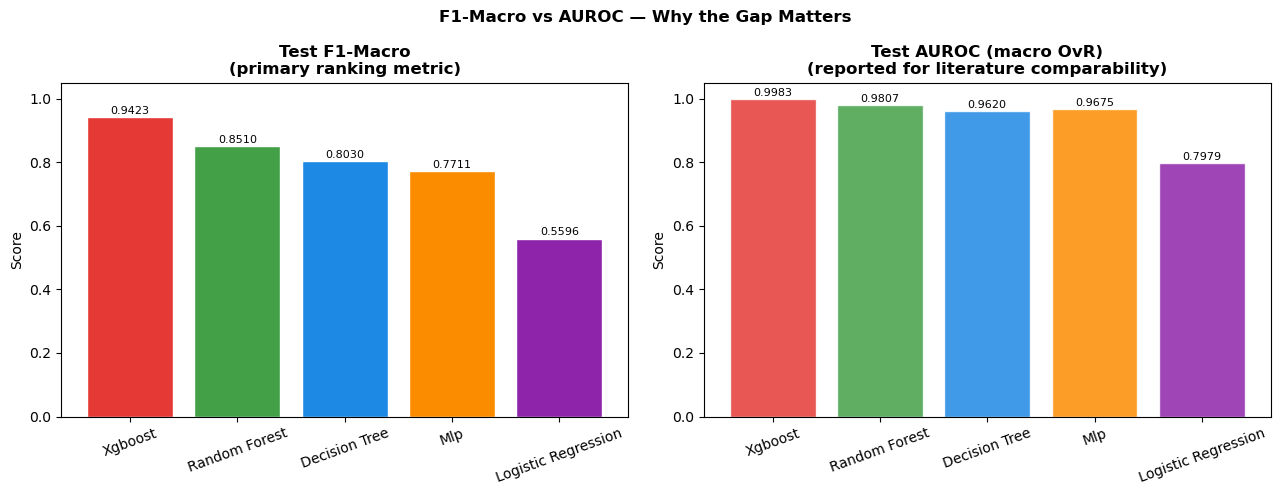

Note: LR has AUROC=0.80 but F1-Macro=0.56 — it discriminates classes
probabilistically but fails at hard classification, especially for Critical.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

names   = results_df['Model'].tolist()
x       = np.arange(len(names))
width   = 0.35

# F1-Macro
bars1 = axes[0].bar(names, results_df['F1-Macro'],
                    color=MODEL_COLORS[:len(names)], edgecolor='white')
axes[0].set_title('Test F1-Macro\n(primary ranking metric)', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars1, results_df['F1-Macro']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=8)

# AUROC
bars2 = axes[1].bar(names, results_df['AUROC'],
                    color=MODEL_COLORS[:len(names)], edgecolor='white', alpha=0.85)
axes[1].set_title('Test AUROC (macro OvR)\n(reported for literature comparability)', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars2, results_df['AUROC']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=8)

plt.suptitle('F1-Macro vs AUROC — Why the Gap Matters', fontweight='bold')
plt.tight_layout()
plt.show()

print('Note: LR has AUROC=0.80 but F1-Macro=0.56 — it discriminates classes')
print('probabilistically but fails at hard classification, especially for Critical.')

## 3. Critical Class — Recall vs Precision Trade-off

The clinical tension: high recall catches more critical patients (fewer dangerous misses) but lowers precision (more false alarms → alert fatigue). This plot makes that trade-off visible across all models.

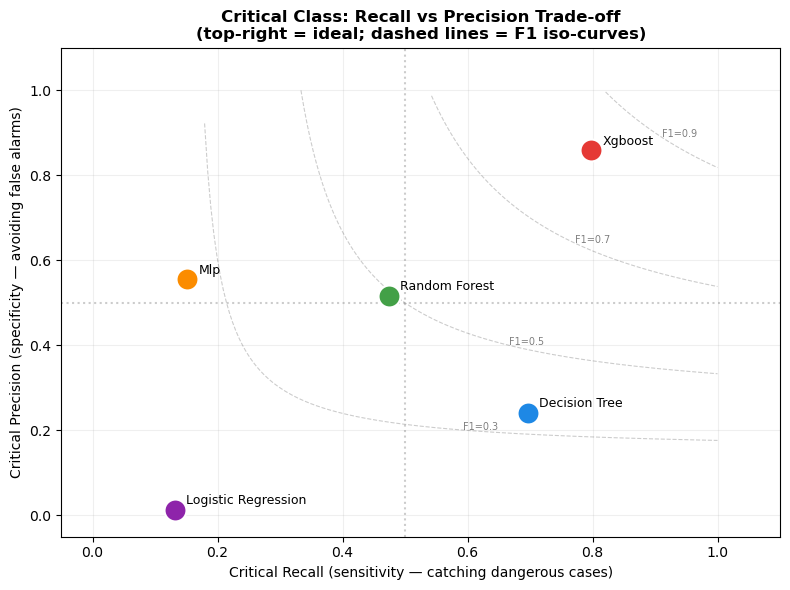

XGBoost sits closest to top-right (high recall AND high precision).
Decision Tree has high recall but low precision — over-alerts.
MLP and LR have both low — they essentially miss Critical cases entirely.


In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

for i, row in results_df.iterrows():
    ax.scatter(row['Critical Recall'], row['Critical Precision'],
               s=250, color=MODEL_COLORS[i], zorder=5,
               edgecolors='white', linewidth=1.5)
    ax.annotate(row['Model'],
                (row['Critical Recall'], row['Critical Precision']),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

# F1 iso-lines
recall_range = np.linspace(0.01, 1.0, 200)
for f1_target in [0.3, 0.5, 0.7, 0.9]:
    precision_vals = f1_target * recall_range / (2 * recall_range - f1_target)
    mask = (precision_vals >= 0) & (precision_vals <= 1)
    ax.plot(recall_range[mask], precision_vals[mask],
            'k--', alpha=0.2, linewidth=0.8)
    if mask.any():
        mid = len(recall_range[mask]) // 2
        ax.text(recall_range[mask][mid], precision_vals[mask][mid],
                f'F1={f1_target}', fontsize=7, alpha=0.5)

ax.set_xlabel('Critical Recall (sensitivity — catching dangerous cases)', fontsize=10)
ax.set_ylabel('Critical Precision (specificity — avoiding false alarms)', fontsize=10)
ax.set_title('Critical Class: Recall vs Precision Trade-off\n'
             '(top-right = ideal; dashed lines = F1 iso-curves)', fontweight='bold')
ax.set_xlim(-0.05, 1.1)
ax.set_ylim(-0.05, 1.1)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.4)
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.4)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print('XGBoost sits closest to top-right (high recall AND high precision).')
print('Decision Tree has high recall but low precision — over-alerts.')
print('MLP and LR have both low — they essentially miss Critical cases entirely.')

## 4. Confusion Matrices — All Models

Shows exactly where each model makes errors. The most dangerous error type is the bottom-left cell: predicting Low when the true label is Critical.

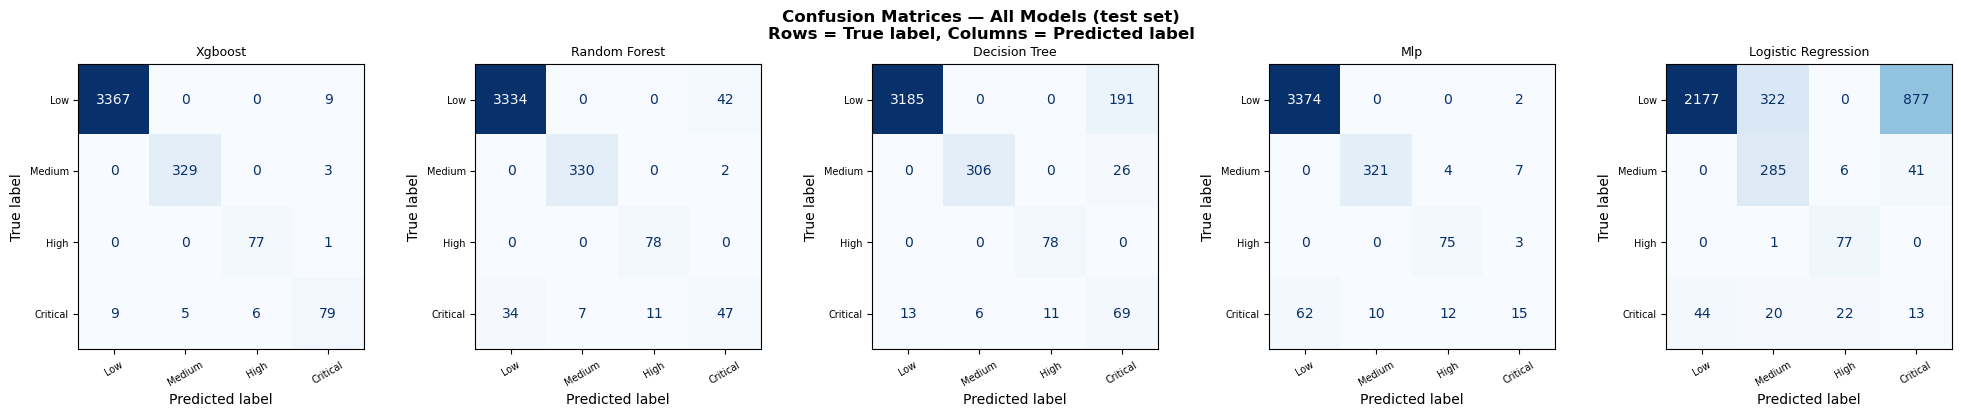

Key error to watch: bottom-left cell in each matrix.
That is Critical patients predicted as Low — the most dangerous miss.


In [5]:
fitted_models = {}
for name in MODEL_ORDER:
    model_path = f'../models/{name}_best.joblib'
    try:
        fitted_models[name] = joblib.load(model_path)
    except FileNotFoundError:
        print(f'  Skipping {name} — model file not found.')

n_models = len(fitted_models)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test)
    disp   = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=LABELS,
        ax=ax,
        colorbar=False,
        cmap='Blues',
    )
    ax.set_title(name.replace('_', ' ').title(), fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Confusion Matrices — All Models (test set)\n'
             'Rows = True label, Columns = Predicted label',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('Key error to watch: bottom-left cell in each matrix.')
print('That is Critical patients predicted as Low — the most dangerous miss.')

## 5. Per-Class F1 Heatmap

Shows each model's F1 score per urgency class. Reveals where models struggle specifically — not just overall.

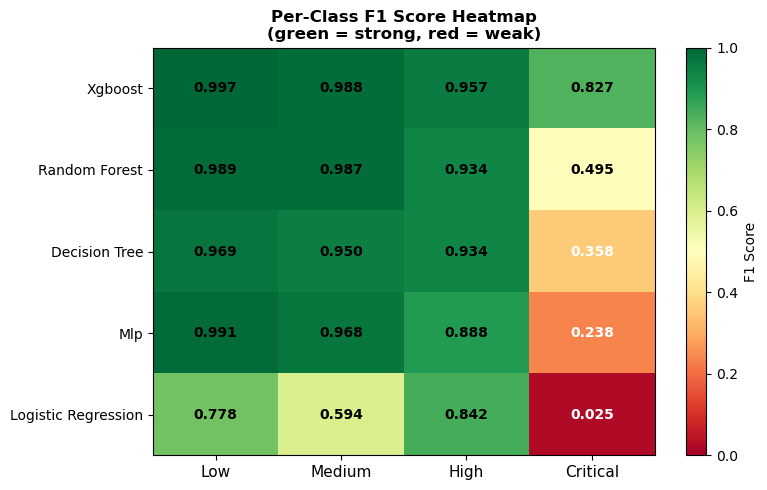

All models score well on Low (dominant class).
The critical differentiator is performance on High and Critical.
XGBoost is the only model maintaining strong F1 across all 4 classes.


In [6]:
f1_matrix = []
model_names = []

for name in MODEL_ORDER:
    if name not in test_results:
        continue
    per_class = test_results[name].get('per_class', {})
    row = [per_class.get(label, {}).get('f1', 0) for label in LABELS]
    f1_matrix.append(row)
    model_names.append(name.replace('_', ' ').title())

f1_arr = np.array(f1_matrix)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(f1_arr, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='F1 Score')

ax.set_xticks(range(len(LABELS)))
ax.set_yticks(range(len(model_names)))
ax.set_xticklabels(LABELS, fontsize=11)
ax.set_yticklabels(model_names, fontsize=10)

for i in range(len(model_names)):
    for j in range(len(LABELS)):
        val = f1_arr[i, j]
        ax.text(j, i, f'{val:.3f}',
                ha='center', va='center', fontsize=10,
                color='white' if val < 0.4 else 'black',
                fontweight='bold')

ax.set_title('Per-Class F1 Score Heatmap\n'
             '(green = strong, red = weak)', fontweight='bold')
plt.tight_layout()
plt.show()

print('All models score well on Low (dominant class).')
print('The critical differentiator is performance on High and Critical.')
print('XGBoost is the only model maintaining strong F1 across all 4 classes.')

## 6. ROC Curves — XGBoost (One-vs-Rest per class)

Separate ROC curve per urgency level for the best model. Shows discrimination ability for each class independently.

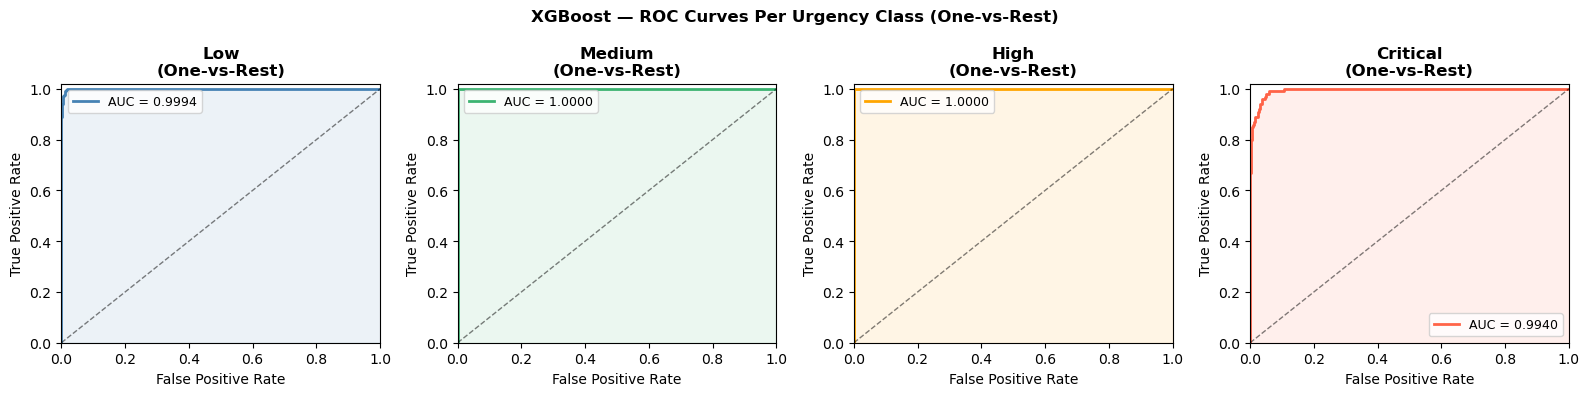

In [7]:
from sklearn.metrics import roc_curve, auc

xgb_model  = fitted_models['xgboost']
y_proba    = xgb_model.predict_proba(X_test)
y_bin      = label_binarize(y_test, classes=[0, 1, 2, 3])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, (ax, label, color) in enumerate(zip(axes, LABELS, URG_COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_title(f'{label}\n(One-vs-Rest)', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('XGBoost — ROC Curves Per Urgency Class (One-vs-Rest)',
             fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Global SHAP — XGBoost

Mean absolute SHAP values across all classes and all test samples. Answers: **which features matter most overall?**

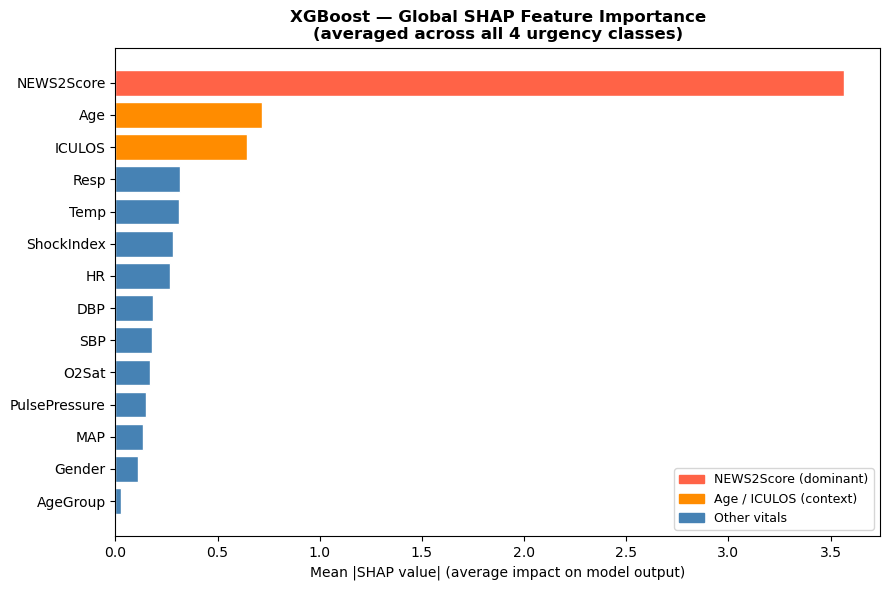

Top 5 global SHAP features:
NEWS2Score    3.5634
Age           0.7152
ICULOS        0.6442
Resp          0.3146
Temp          0.3099


In [8]:
import shap

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Global importance: mean abs SHAP across all classes and samples
if isinstance(shap_values, list):
    abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
else:
    abs_shap = np.abs(shap_values).mean(axis=(0, 2)) if len(shap_values.shape) == 3 else np.abs(shap_values).mean(axis=0)

global_imp = pd.Series(abs_shap, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['tomato' if f == 'NEWS2Score' else
          'darkorange' if f in ['Age', 'ICULOS'] else
          'steelblue' for f in global_imp.index]
ax.barh(global_imp.index, global_imp.values, color=colors, edgecolor='white')
ax.set_xlabel('Mean |SHAP value| (average impact on model output)')
ax.set_title('XGBoost — Global SHAP Feature Importance\n'
             '(averaged across all 4 urgency classes)', fontweight='bold')

patches = [
    mpatches.Patch(color='tomato',     label='NEWS2Score (dominant)'),
    mpatches.Patch(color='darkorange', label='Age / ICULOS (context)'),
    mpatches.Patch(color='steelblue',  label='Other vitals'),
]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.show()

print('Top 5 global SHAP features:')
print(global_imp.sort_values(ascending=False).head().round(4).to_string())

## 8. Per-Class SHAP — The Key Clinical Finding

This is the most clinically meaningful explainability result. For each urgency level, which features specifically push the model toward that classification?

**The finding:** NEWS2Score dominates for Low/Medium/High, but drops to position 5 for Critical — where Age and ICULOS take over. This reveals that sepsis-driven critical deterioration is context-dependent, not just vital-sign-driven.

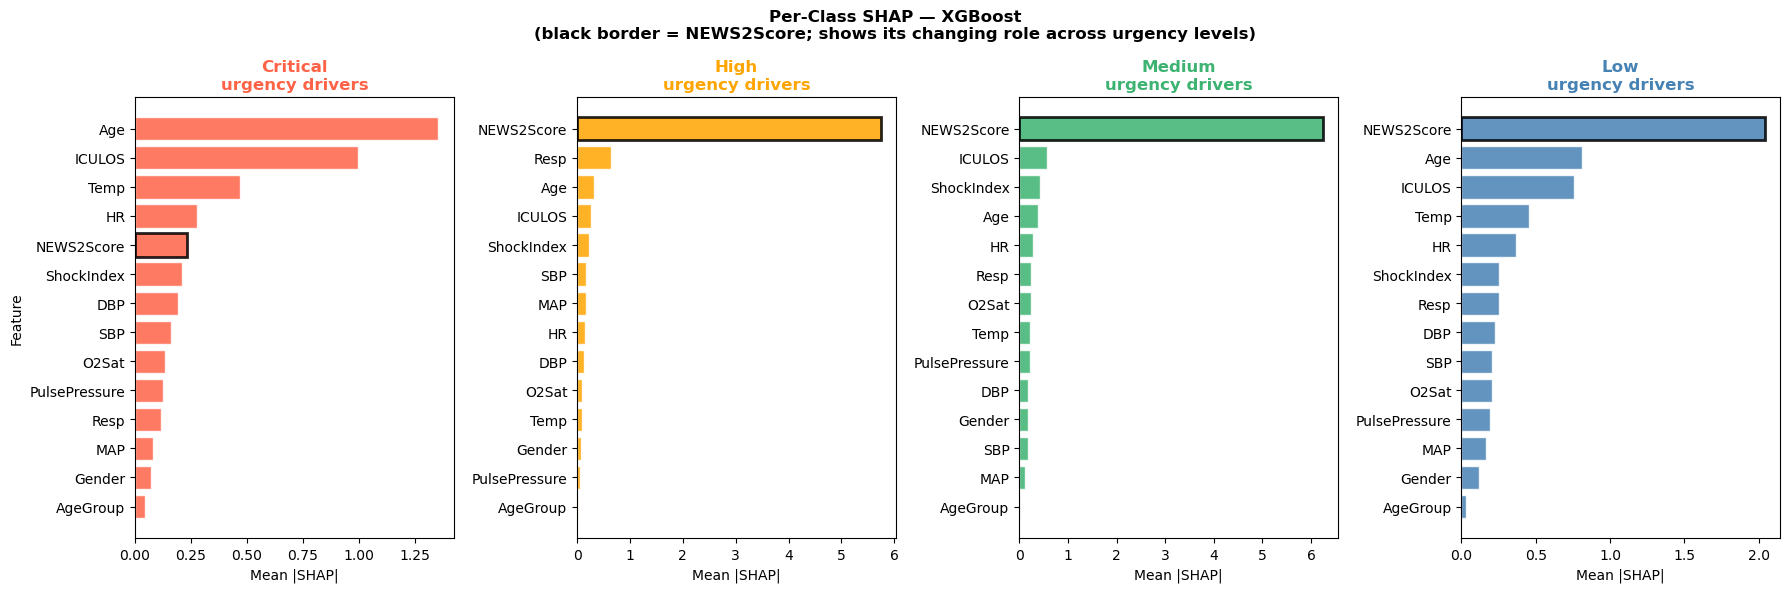

NEWS2Score SHAP values per class:
  Low        : 2.0408
  Medium     : 6.2401
  High       : 5.7406
  Critical   : 0.2323

Headline finding: NEWS2Score drives Low/Medium/High predictions.
For Critical, it drops — Age and ICULOS take over.
This means sepsis-driven criticality is context-dependent, not just vital-severity-driven.
A pure NEWS2 cutoff would miss these patients.


In [9]:
# Per-class SHAP: shap_values[class_idx] has shape (n_samples, n_features)
class_order = [3, 2, 1, 0]  # Critical first for visual impact
class_names = {3: 'Critical', 2: 'High', 1: 'Medium', 0: 'Low'}

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for ax, cls_idx in zip(axes, class_order):
    sv      = np.abs((shap_values[:, :, cls_idx] if len(shap_values.shape) == 3 else shap_values[cls_idx]))
    mean_sv = sv.mean(axis=0)
    imp     = pd.Series(mean_sv, index=FEATURES).sort_values(ascending=True)
    color   = URG_COLORS[cls_idx]

    bars = ax.barh(imp.index, imp.values, color=color,
                   edgecolor='white', alpha=0.85)

    # Highlight NEWS2Score
    for bar, feat in zip(bars, imp.index):
        if feat == 'NEWS2Score':
            bar.set_edgecolor('black')
            bar.set_linewidth(2)

    ax.set_title(f'{class_names[cls_idx]}\nurgency drivers',
                 fontweight='bold', color=color)
    ax.set_xlabel('Mean |SHAP|')
    if ax == axes[0]:
        ax.set_ylabel('Feature')

plt.suptitle('Per-Class SHAP — XGBoost\n'
             '(black border = NEWS2Score; shows its changing role across urgency levels)',
             fontweight='bold')
plt.tight_layout()
plt.show()

# Print the headline finding
print('NEWS2Score SHAP values per class:')
news2_idx = FEATURES.index('NEWS2Score')
for cls_idx in [0, 1, 2, 3]:
    sv_mean = np.abs((shap_values[:, :, cls_idx] if len(shap_values.shape) == 3 else shap_values[cls_idx])).mean(axis=0)[news2_idx]
    print(f'  {class_names[cls_idx]:<10} : {sv_mean:.4f}')

print()
print('Headline finding: NEWS2Score drives Low/Medium/High predictions.')
print('For Critical, it drops — Age and ICULOS take over.')
print('This means sepsis-driven criticality is context-dependent, not just vital-severity-driven.')
print('A pure NEWS2 cutoff would miss these patients.')

## 9. SHAP Waterfall — Single Patient Example

For one Critical patient, show how each feature contributed to the Critical classification. This is the 'explanation for a single prediction' that a clinician would see in a deployed system.

Patient row index: 104
True label  : Critical (3)
Predicted   : 3 (Critical)

Vital values for this patient:
                   104
HR            0.726459
O2Sat        -0.402129
Temp          1.137255
SBP          -1.203659
Resp         -0.167105
NEWS2Score    0.518688
Age          40.130000
ICULOS      147.000000

SHAP contribution toward Critical classification:


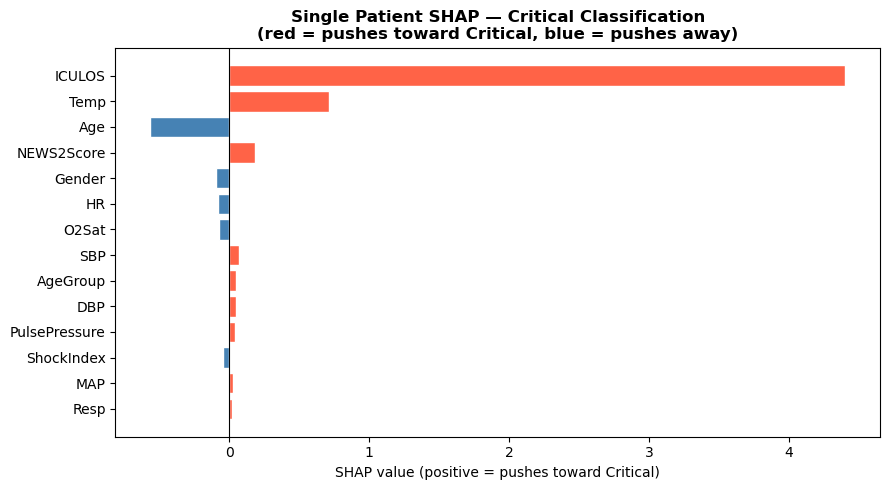

In [10]:
# Pick a correctly classified Critical patient
y_pred         = xgb_model.predict(X_test)
correct_crit   = np.where((y_test.values == 3) & (y_pred == 3))[0]

if len(correct_crit) == 0:
    print('No correctly classified Critical patients found in test set.')
else:
    sample_idx    = correct_crit[0]
    sample_row    = X_test.iloc[[sample_idx]]
    sample_shap   = explainer(sample_row)

    print(f'Patient row index: {sample_idx}')
    print(f'True label  : Critical (3)')
    print(f'Predicted   : {y_pred[sample_idx]} ({["Low","Medium","High","Critical"][y_pred[sample_idx]]})')
    print(f'\nVital values for this patient:')
    print(sample_row[['HR', 'O2Sat', 'Temp', 'SBP', 'Resp', 'NEWS2Score', 'Age', 'ICULOS']].T.to_string())

    # SHAP waterfall for the Critical class (index 3)
    print('\nSHAP contribution toward Critical classification:')
    shap_contrib = pd.Series(
        (shap_values[sample_idx, :, 3] if len(shap_values.shape) == 3 else shap_values[3][sample_idx]),
        index=FEATURES
    ).sort_values(key=abs, ascending=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    colors  = ['tomato' if v > 0 else 'steelblue' for v in shap_contrib.values]
    ax.barh(shap_contrib.index[::-1], shap_contrib.values[::-1],
            color=colors[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value (positive = pushes toward Critical)')
    ax.set_title(f'Single Patient SHAP — Critical Classification\n'
                 f'(red = pushes toward Critical, blue = pushes away)',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()

## 10. Summary — Key Findings

Final synthesis of all evaluation and explainability results.

In [11]:
print('=' * 65)
print('  PHASE 1 — KEY FINDINGS SUMMARY')
print('=' * 65)

print('''
1. BEST MODEL: XGBoost
   F1-Macro: 0.9423 | AUROC: 0.9983
   Critical Recall: 0.7980 | Critical Precision: 0.8587
   → Catches 4 in 5 critical patients. Best across all metrics.

2. INTERPRETABILITY RUNNER-UP: Decision Tree
   F1-Macro: 0.8030 | Critical Recall: 0.6970 (but Precision: 0.24)
   → Over-alerts but misses fewer critical cases than MLP/LR.
   → Rule paths are clinically readable (root split on NEWS2Score).
   → Viable for low-resource settings where explainability > accuracy.

3. NEURAL/LINEAR MODELS FAIL ON CRITICAL:
   MLP Critical Recall: 0.1515 | LR Critical Recall: 0.1313
   → Both essentially miss Critical cases despite class weighting.
   → Confirms: non-linear ensemble methods are necessary for this task.

4. HEADLINE SHAP FINDING:
   NEWS2Score drives Low/Medium/High predictions (SHAP: 2.0–6.2).
   For Critical, Age + ICULOS dominate (NEWS2Score drops to 0.23).
   → Sepsis-driven criticality is context-dependent.
   → A pure NEWS2 cutoff systematically misses sepsis-onset cases.
   → This is the primary justification for ML over rule-based triage.

5. METRIC LESSON (literature validated):
   LR achieves AUROC=0.80 but F1-Macro=0.56.
   Over-reliance on AUROC would make LR look acceptable.
   F1-Macro and Critical Recall are the honest clinical metrics here.
''')
print('=' * 65)
print('  Next: Full 40k-patient run | Patient-level split | Phase 2')
print('=' * 65)

  PHASE 1 — KEY FINDINGS SUMMARY

1. BEST MODEL: XGBoost
   F1-Macro: 0.9423 | AUROC: 0.9983
   Critical Recall: 0.7980 | Critical Precision: 0.8587
   → Catches 4 in 5 critical patients. Best across all metrics.

2. INTERPRETABILITY RUNNER-UP: Decision Tree
   F1-Macro: 0.8030 | Critical Recall: 0.6970 (but Precision: 0.24)
   → Over-alerts but misses fewer critical cases than MLP/LR.
   → Rule paths are clinically readable (root split on NEWS2Score).
   → Viable for low-resource settings where explainability > accuracy.

3. NEURAL/LINEAR MODELS FAIL ON CRITICAL:
   MLP Critical Recall: 0.1515 | LR Critical Recall: 0.1313
   → Both essentially miss Critical cases despite class weighting.
   → Confirms: non-linear ensemble methods are necessary for this task.

4. HEADLINE SHAP FINDING:
   NEWS2Score drives Low/Medium/High predictions (SHAP: 2.0–6.2).
   For Critical, Age + ICULOS dominate (NEWS2Score drops to 0.23).
   → Sepsis-driven criticality is context-dependent.
   → A pure NEWS2